In [209]:
import mujoco
import mediapy as media
import numpy as np
from enviornment_randomizer import Enviornment_Randomizer

In [210]:

randomizer = Enviornment_Randomizer()
xml= 'xml_models/world.xml'
model = mujoco.MjModel.from_xml_path(xml)

In [211]:
#getting names
[model.geom(i).name for i in range(model.ngeom)]

['ground_plane',
 '1bottom_l',
 '1top_l',
 '1bottom_r',
 '1top_r',
 '1table_top_geom',
 '1base_geom',
 '1base_plate_geom',
 '1camera_stand_geom',
 'apriltag_36h11_0',
 'plate_visual_geom',
 'plate_collision_geom',
 'full_slice_slice',
 'deformed_slice_slice',
 'rod_rod',
 'block_block',
 'full_slice_2slice',
 'deformed_slice_2slice',
 'rod_2rod',
 'block_2block']

**RANDOM COLOR TEST**

In [ ]:
model = randomizer.randomize_color_of_single_geom(model=model, geom_name='1table_top_geom')
#creating the data
data = mujoco.MjData(model)
#forwarding the data, we only need lights and positions so we need forward
mujoco.mj_forward(model, data)



""

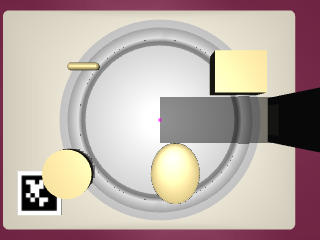

In [213]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

**RANDOM NUMBER OF OBJECTS CHECKING**

In [214]:
body_names = [model.body(i).name for i in range(model.nbody)]
print(body_names)
"""THIS LISTS ALL THE BODIES IN THE SCENE: BUT 3X for FOOD
THERE IS THE PARENT BODY IN WORLD.XML, THE BODY CREATED IN THE FOOD.XML(BC OF ATTACH)
AND THE GEOM BODY CREATED IN THE WORLD.XML (BC OF ATTACH)"""

['world', 'table', '1table', '1bottom left', '1top left', '1bottom right', '1top right', '1table top', 'base_camera_stand_instance', 'apriltag_3611_0', 'plate', 'full_slice_instance', 'full_slice_block', 'deformed_slice_instance', 'deformed_slice_slice', 'rod_instance', 'rod_rod', 'block_instance', 'block_block', 'full_slice_instance_2', 'full_slice_2block', 'deformed_slice_instance_2', 'deformed_slice_2slice', 'rod_instance_2', 'rod_2rod', 'block_instance_2', 'block_2block']


'THIS LISTS ALL THE BODIES IN THE SCENE: BUT 3X for FOOD\nTHERE IS THE PARENT BODY IN WORLD.XML, THE BODY CREATED IN THE FOOD.XML(BC OF ATTACH)\nAND THE GEOM BODY CREATED IN THE WORLD.XML (BC OF ATTACH)'

In [215]:
list_of_bodies = [
    "full_slice_instance",
    "deformed_slice_instance",
    "rod_instance",
    "block_instance",
    "full_slice_instance_2",
    "deformed_slice_instance_2",
    "rod_instance_2",
    "block_instance_2",
]

list_of_bodies = np.array(list_of_bodies)
model = randomizer.randomize_number_of_objects(list_of_food_object_names=list_of_bodies, 
model=model,min_objects=1, in_secene_z_cord=0.18, out_of_scene_z_cord=-0.18)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)


""

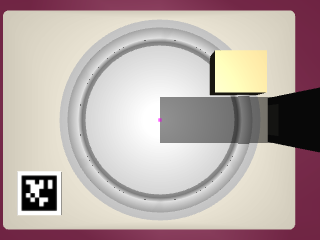

In [216]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

""

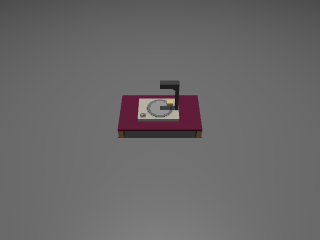

In [217]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data)
    image = renderer.render()

media.show_image(image)

**RANDOM POSITION**

In [218]:
list_of_bodies = [
    "full_slice_instance",
    "deformed_slice_instance",
    "rod_instance",
    "block_instance",
    "full_slice_instance_2",
    "deformed_slice_instance_2",
    "rod_instance_2",
    "block_instance_2",
]
#KEEPING DEFAULT PLATE
model = randomizer.randomize_position_of_objects(list_of_food_object_names=list_of_bodies, 
model=model)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

""

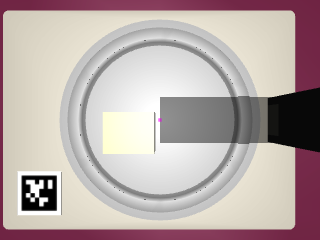

In [219]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)

**RANDOMIZE COLOR OF OBJECTS**

In [ ]:
randomizer.randomize_color_of_multiple_bodies_with_single_geom(model, list_of_body_names=list_of_bodies)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

In [ ]:
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera="emeet_c960_camera")
    image = renderer.render()

media.show_image(image)